In [1]:
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 
# 增加环境变量  D:\anaconda\envs\tf2\Scripts

In [2]:
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [3]:
import random
import time

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
# settings
env_id  = "CartPole-v1"

# number of environments to run in parallel
num_envs = 1

# total number of timesteps for training over multiple episodes
total_timesteps = 100_000

# adam learning rate
learning_rate = 2e-3

# number of transitions to store in replay buffer
buffer_size = 10_000

# discount factor
gamma = 0.99

# target network update constant
# θ_target = 𝜏 * θ + (1 - 𝜏) * θ_target
tau = 1.0

# number of timesteps between target network updates
target_network_frequency = 50

# size of sample from replay buffer
batch_size = 32

# initial value of epsilon (100% exploration)
start_eps = 1

# final value of epsilon (1% exploration)
end_eps = 0.01

# number of steps to decrease from start_eps to end_eps
exploration_duration = int(0.1 * total_timesteps)

# number of steps before beginning training
num_steps_before_training = 5_000

# number of steps between each gradient descent step
train_frequency = 4

# optional: set seed for reproducibility
# seed = 123
seed = None

video_path = "dqn_cartpole_videos"

In [5]:
# will encapsulate in lambda later
def make_env(env_id, capture_video, seed=None):
    if capture_video:
        env = gym.make(env_id, render_mode="rgb_array")
        env = gym.wrappers.RecordVideo(env, video_path,
            episode_trigger=lambda episode: True)
        # ensure it records all episodes, by default it only records every 1000th
    else:
        env = gym.make(env_id)
    env = gym.wrappers.RecordEpisodeStatistics(env)

    # To get reproducible sampling of actions, a seed can be set with env.action_space.seed(123)
    if seed is not None:
        env.action_space.seed(seed)
    return env

In [6]:
class QNetwork(nn.Module):
    def __init__(self, envs, n_hidden=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(envs.single_observation_space.shape[0], n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, envs.single_action_space.n),
        )

    def forward(self, x):
        return self.network(x)

In [7]:
def linear_schedule(start_eps, end_eps, duration, t):
    slope = (end_eps - start_eps) / duration
    return max(slope * t + start_eps, end_eps)

In [8]:
envs = gym.vector.SyncVectorEnv([
    lambda: make_env(
        env_id, False,
        seed if seed is None else seed + i) for i in range(num_envs)
])

In [9]:
# set device
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    # "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [10]:
device

device(type='cuda')

In [11]:
# make neural networks
q_network = QNetwork(envs).to(device)
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
target_network = QNetwork(envs).to(device)
target_network.load_state_dict(q_network.state_dict()) # copy main to target

D:\anaconda\envs\tf2\lib\site-packages\torch\cuda\__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


<All keys matched successfully>

In [12]:
class ReplayBuffer:
    def __init__(self, obs_dim, size):
        self.obs1_buf = np.zeros([size, obs_dim], dtype=np.float32)
        self.obs2_buf = np.zeros([size, obs_dim], dtype=np.float32)
        self.acts_buf = np.zeros(size, dtype=np.uint8)
        self.rews_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.uint8)
        self.ptr, self.size, self.max_size = 0, 0, size

    def store(self, obs, act, rew, next_obs, done):
        self.obs1_buf[self.ptr] = obs
        self.obs2_buf[self.ptr] = next_obs
        self.acts_buf[self.ptr] = act
        self.rews_buf[self.ptr] = rew
        self.done_buf[self.ptr] = done
        self.ptr = (self.ptr+1) % self.max_size
        self.size = min(self.size+1, self.max_size)

    def sample_batch(self, batch_size=32):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return dict(s=self.obs1_buf[idxs],
                    s2=self.obs2_buf[idxs],
                    a=self.acts_buf[idxs],
                    r=self.rews_buf[idxs],
                    d=self.done_buf[idxs])

In [13]:
rb = ReplayBuffer(
    envs.single_observation_space.shape[0],
    buffer_size,
)

In [14]:
def np2torch(a, to_float=True):
  if to_float:
    dtype = torch.float32
  else:
    dtype = torch.int64
  return torch.as_tensor(a, dtype=dtype, device=device)

In [15]:
# training loop

episode_returns = []
losses = []

start_time = time.time()
obs, _ = envs.reset(seed=seed)
autoreset = np.zeros(num_envs, dtype=bool)

for global_step in range(total_timesteps):

  # select an action based on epsilon-greedy
  epsilon = linear_schedule(start_eps, end_eps, exploration_duration, global_step)
  if random.random() < epsilon:
    actions = np.array([envs.single_action_space.sample() for _ in range(num_envs)])
  else:
    q_values = q_network(np2torch(obs))
    actions = torch.argmax(q_values, dim=1).cpu().numpy()

  # take a step in the environment
  next_obs, rewards, dones, truncateds, infos = envs.step(actions)

  # record returns for plotting
  for i, (done, truncated) in enumerate(zip(dones, truncateds)):
    if done or truncated:
      ret = infos["episode"]["r"][i]
      episode_returns.append(ret)
      print(f"global_step={global_step}, episode={len(episode_returns)}, episode_return={ret}")

  # update the replay buffer
  for i in range(num_envs):
    if not autoreset[i]:
      rb.store(obs[i], actions[i], rewards[i], next_obs[i], dones[i])

  # don't forget
  obs = next_obs

  # update autoreset
  autoreset = np.logical_or(dones, truncateds)

  # training
  if global_step > num_steps_before_training:
    if global_step % train_frequency == 0:
      batch = rb.sample_batch(batch_size)
      with torch.no_grad():
        target_max, _ = target_network(np2torch(batch["s2"])).max(dim=1)
        td_target = np2torch(batch["r"].flatten()) + \
        gamma * target_max * np2torch(1 - batch["d"].flatten())

      a = np2torch(batch['a'], to_float=False)
      a = a.reshape(-1, 1)
      s = np2torch(batch['s'])
      qsa = q_network(s)
      # want: Q(s, a) where a is the action done
      # np syntax: Qs[:, a]
      pred = qsa.gather(1, a).squeeze()
      loss = F.mse_loss(pred, td_target)
      losses.append(loss.item())

      # optimize the model
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    if global_step % 1000 == 0:
      print("steps per second:", int(global_step / (time.time() - start_time)))

    # update the target network
    if global_step % target_network_frequency == 0:
      for target_network_param, q_network_param in zip(target_network.parameters(), q_network.parameters()):
        target_network_param.data.copy_(
            tau * q_network_param.data + (1.0 - tau) * target_network_param.data
        )

    # let's just break if the last 10 episodes had max reward
    if len(episode_returns) > 10 and np.all(np.equal(episode_returns[-10:], 500)):
        print("max reward achieved")
        break

global_step=12, episode=1, episode_return=13.0
global_step=25, episode=2, episode_return=12.0
global_step=41, episode=3, episode_return=15.0
global_step=93, episode=4, episode_return=51.0
global_step=128, episode=5, episode_return=34.0
global_step=150, episode=6, episode_return=21.0
global_step=174, episode=7, episode_return=23.0
global_step=190, episode=8, episode_return=15.0
global_step=202, episode=9, episode_return=11.0
global_step=220, episode=10, episode_return=17.0
global_step=238, episode=11, episode_return=17.0
global_step=267, episode=12, episode_return=28.0
global_step=293, episode=13, episode_return=25.0
global_step=304, episode=14, episode_return=10.0
global_step=324, episode=15, episode_return=19.0
global_step=342, episode=16, episode_return=17.0
global_step=363, episode=17, episode_return=20.0
global_step=390, episode=18, episode_return=26.0
global_step=427, episode=19, episode_return=36.0
global_step=458, episode=20, episode_return=30.0
global_step=471, episode=21, epis

In [39]:
# close env
envs.close()

In [17]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1 - a) * y[-1]
        y.append(yi)
    return y

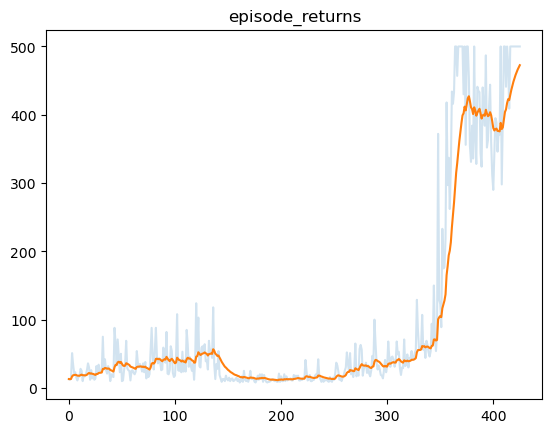

In [18]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");
plt.show();

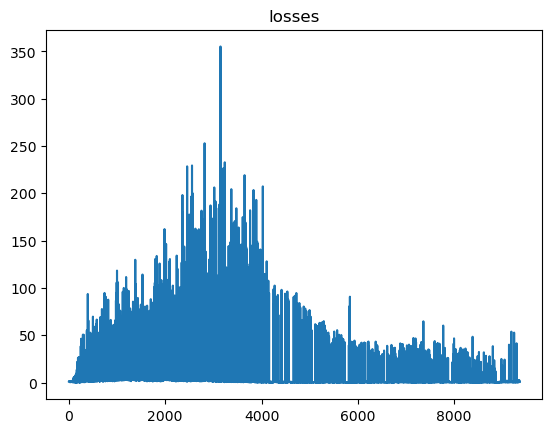

In [19]:
plt.plot(losses)
plt.title("losses");
plt.show();

In [20]:
# save model
model_path = "dqn_cartpole.pth"
torch.save(q_network.state_dict(), model_path)

In [21]:
# load model for eval + create test env
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)])
model = QNetwork(envs_eval)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

D:\anaconda\envs\tf2\lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at E:\reinforcing\notebooks\rl2v2\dqn_cartpole_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
C:\Users\yxzha\AppData\Local\Temp\ipykernel_38752\3314097281.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.seria

QNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [22]:
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
inputs = np2torch(obs).to(device)
# 统一设备和模型

for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    inputs = np2torch(obs).to(device)
    q_values = model(inputs)
    actions = torch.argmax(q_values, dim=1).cpu().numpy()
    obs, rewards, dones, truncateds, infos = envs_eval.step(actions)

    if dones[0] or truncateds[0]:
      G = infos["episode"]["r"][0]
      eval_returns[i] = G
      print(f"episode={i}, return={G}")
      episode_done = True

# close env
envs_eval.close()

episode=0, return=371.0
episode=1, return=292.0
episode=2, return=324.0
episode=3, return=334.0
episode=4, return=306.0
episode=5, return=325.0
episode=6, return=345.0
episode=7, return=371.0
episode=8, return=288.0
episode=9, return=342.0


In [23]:
device

device(type='cuda')

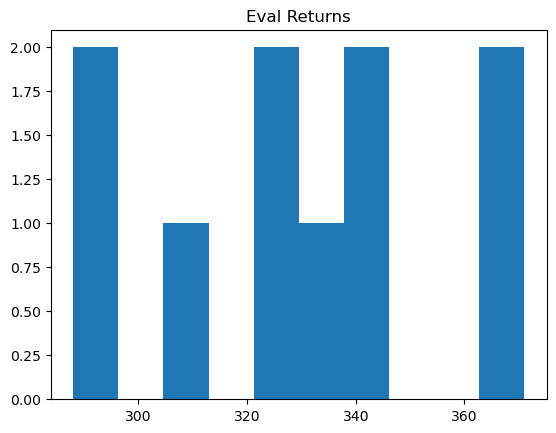

In [24]:
# plot the eval returns distribution
plt.hist(eval_returns)
plt.title("Eval Returns")
plt.show();

In [25]:
# prompt: display video in colab notebook with filename "videos/rl-video-episode-0.mp4"

from IPython.display import HTML
from base64 import b64encode

mp4 = open(f'{video_path}/rl-video-episode-5.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=qsKxUjkGj_Qk9wyS1St9Jw&n=DQN+Cartpole)